# CNN - Image Classification (Cat vs Dog)
### Simple and Clean Implementation for Final Exam

## Step 1: Import Libraries

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

## Step 2: Load Dataset

In [9]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    r'D:\Languages\Academic_PSTU_CSE\5th Semester\AI\AI_Lab\CNN\train',
    image_size=(128, 128),  # Resize to 128x128
    batch_size=32
)

# Load test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    r'D:\Languages\Academic_PSTU_CSE\5th Semester\AI\AI_Lab\CNN\test',
    image_size=(128, 128),
    batch_size=32
)

Found 965 files belonging to 2 classes.
Found 99 files belonging to 2 classes.


In [10]:
# Get class names
class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['cats', 'dogs']
Number of classes: 2


## Step 3: Visualize Sample Images

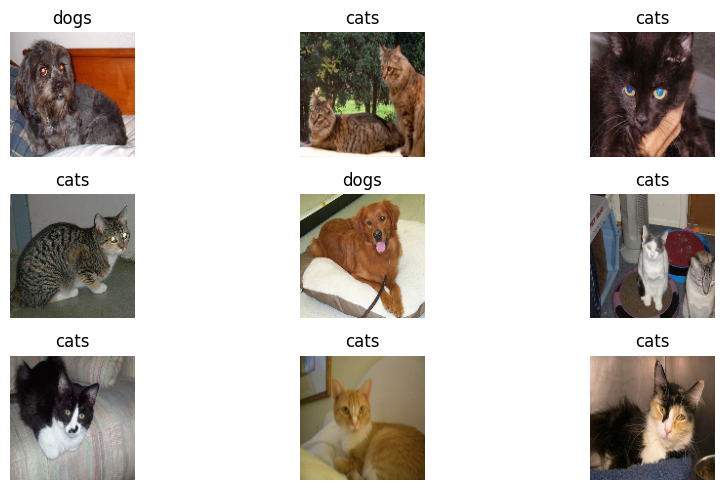

In [11]:
# Display sample images
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Normalize Data (0-255 → 0-1)

In [12]:
# Normalize pixel values
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

# Optimize performance
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

## Step 5: Build CNN Model

In [13]:
model = models.Sequential([
    # Input layer
    layers.Input(shape=(128, 128, 3)),
    
    # Convolutional Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Convolutional Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Convolutional Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile Model

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Step 7: Train Model

In [15]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step - accuracy: 0.5969 - loss: 0.7894 - val_accuracy: 0.5051 - val_loss: 0.6994
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.5969 - loss: 0.6763 - val_accuracy: 0.5051 - val_loss: 0.6994
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.5959 - loss: 0.6632 - val_accuracy: 0.5051 - val_loss: 0.6918
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step - accuracy: 0.6041 - loss: 0.6541 - val_accuracy: 0.5960 - val_loss: 0.6799
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 257ms/step - accuracy: 0.6404 - loss: 0.6314 - val_accuracy: 0.5253 - val_loss: 0.7008
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.6539 - loss: 0.6076 - val_accuracy: 0.5859 - val_loss: 0.6613
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.7109 - loss: 0.5739 - val_accuracy: 0.5556 - val_loss: 0.6820
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.7285 - loss: 0.5320 - val_accuracy: 0

## Step 8: Evaluate Model

In [16]:
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6465 - loss: 0.7350

Test Accuracy: 64.65%
Test Loss: 0.7350


## Step 9: Plot Training History

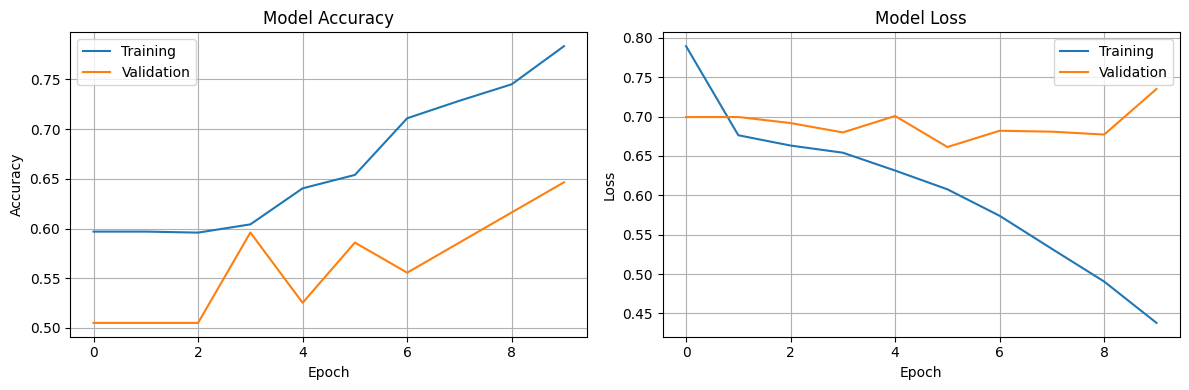

In [17]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 10: Predict on New Images

In [18]:
def predict_image(image_path):
    """Predict class for a single image"""
    
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display original image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # Preprocess
    img_resized = cv2.resize(img, (128, 128))
    img_input = img_resized.reshape((1, 128, 128, 3)) / 255.0
    
    # Predict
    prediction = model.predict(img_input)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = np.max(prediction[0]) * 100
    
    print(f"Predicted: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    
    return predicted_class, confidence

### Test on Cat Image

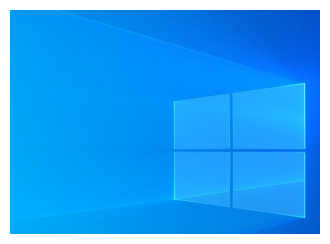

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted: dogs
Confidence: 99.66%


('dogs', np.float32(99.65528))

In [22]:
predict_image('win10.png')

### Test on Dog Image

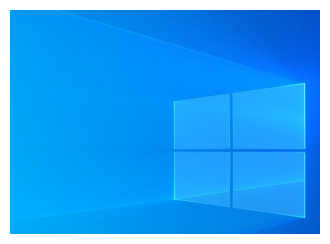

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted: dogs
Confidence: 99.66%


('dogs', np.float32(99.65528))

In [21]:
predict_image('win10.png')

## Step 11: Batch Prediction on Test Set

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


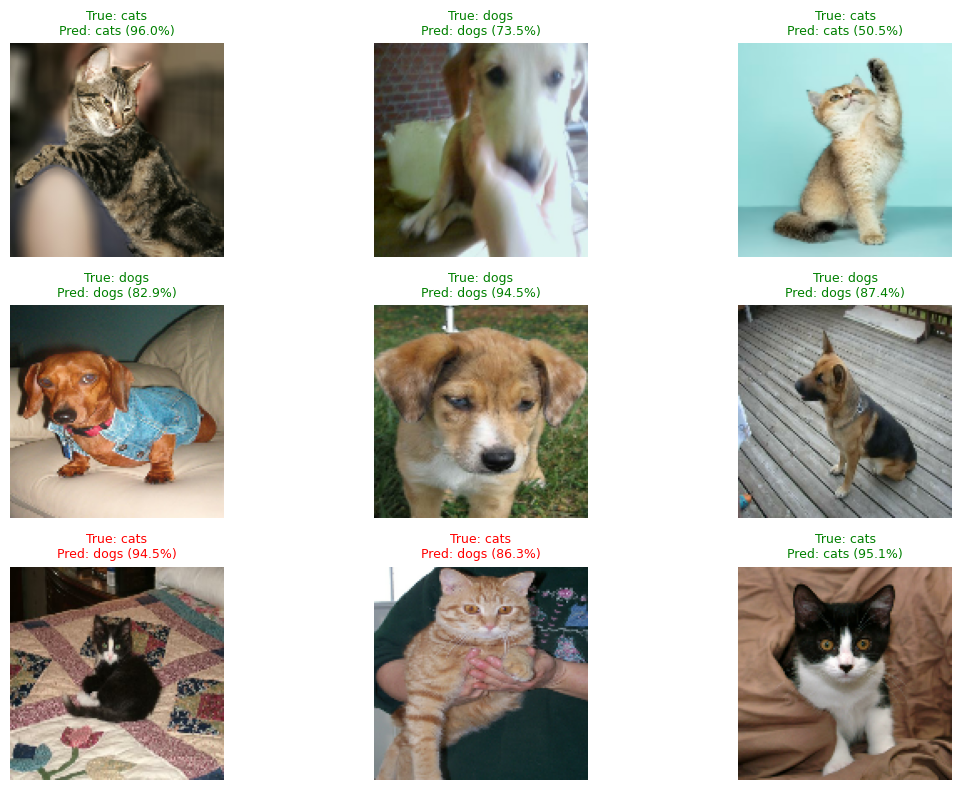

In [23]:
# Show predictions for first batch of test images
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        
        true_label = class_names[labels[i]]
        pred_label = class_names[np.argmax(predictions[i])]
        confidence = np.max(predictions[i]) * 100
        
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
                 color=color, fontsize=9)
        plt.axis('off')

plt.tight_layout()
plt.show()

## Summary

**CNN Architecture:**
- 3 Convolutional layers (32, 64, 128 filters)
- 3 MaxPooling layers (reduce dimensions)
- Flatten layer
- 2 Dense layers (128 neurons + output)

**Key Points:**
- CNNs are better than ANNs for image classification
- Conv2D extracts features (edges, patterns)
- MaxPooling reduces size while keeping important info
- Works great for Cat vs Dog classification!